In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sales_raw_data.csv")

print(df.head())

   Order_ID      Date Customer_Name Region Product  Quantity  Price  \
0      1001  1/1/2025  Rahul Sharma  North  Laptop       2.0  55000   
1      1002  2/1/2025   Priya Singh  north  Mobile       3.0  15000   
2      1003  3/1/2025   Arjun Kumar  South  Tablet       NaN  22000   
3      1004  4/1/2025    Neha Verma   East  Laptop       1.0  55000   
4      1005  5/1/2025  Rahul Sharma  North  Laptop       2.0  55000   

  Salesperson Payment_Status  
0        Amit           Paid  
1         Raj           paid  
2        Amit        Pending  
3         NaN           Paid  
4        Amit           Paid  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        7 non-null      int64  
 1   Date            7 non-null      str    
 2   Customer_Name   7 non-null      str    
 3   Region          7 non-null      str    
 4   Product         7 non-null      str    
 5   Quantity        6 non-null      float64
 6   Price           7 non-null      int64  
 7   Salesperson     6 non-null      str    
 8   Payment_Status  7 non-null      str    
dtypes: float64(1), int64(2), str(6)
memory usage: 636.0 bytes


In [4]:
df.isnull().sum()

Order_ID          0
Date              0
Customer_Name     0
Region            0
Product           0
Quantity          1
Price             0
Salesperson       1
Payment_Status    0
dtype: int64

In [5]:
df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

In [6]:
df["Salesperson"] = df["Salesperson"].fillna(
    "Unknown"
)

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df = df.drop_duplicates()

In [9]:
df["Region"] = df["Region"].str.title()

In [10]:
df["Payment_Status"] = (
    df["Payment_Status"]
    .str.title()
)

In [11]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

In [12]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

In [13]:
df.isnull().sum()

Order_ID          0
Date              0
Customer_Name     0
Region            0
Product           0
Quantity          0
Price             0
Salesperson       0
Payment_Status    0
Revenue           0
dtype: int64

In [14]:
df.to_csv(
    "sales_cleaned_data.csv",
    index=False
)

In [15]:
sales_summary = df.groupby(
    "Region"
)["Revenue"].sum()

print(sales_summary)

Region
East      55000.0
North    265000.0
South     44000.0
West      15000.0
Name: Revenue, dtype: float64


In [16]:
product_report = df.groupby(
    "Product"
)["Revenue"].sum()

print(product_report)

Product
Laptop    275000.0
Mobile     60000.0
Tablet     44000.0
Name: Revenue, dtype: float64


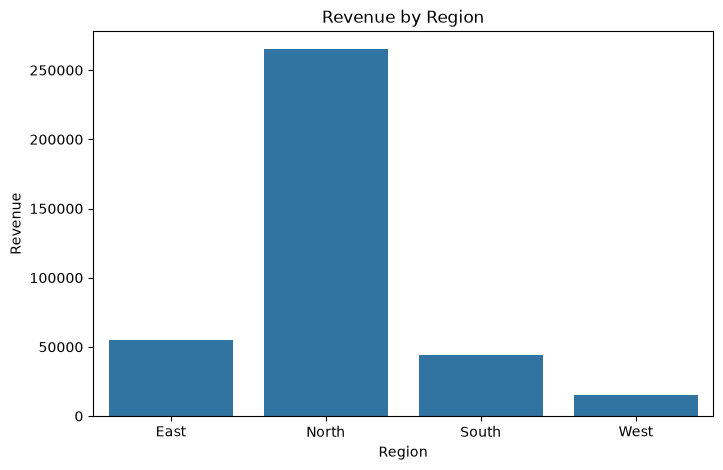

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sales_summary.index,
    y=sales_summary.values
)

plt.title(
    "Revenue by Region"
)

plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()